In [55]:
!pip install -U langchain langchain-community langchain-core langgraph langchain-google-genai langchain-text-splitters faiss-cpu pypdf python-dotenv

In [54]:
!pip install -U langchain-google-genai google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.11.0
    Uninstalling google-genai-2.11.0:
      Successfully uninstalled google-genai-2.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [56]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [57]:
load_dotenv()

True

In [58]:
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [59]:
loader=PyPDFLoader("ai_engineering_guide.pdf")
docs=loader.load()

In [60]:
len(docs)

2

In [61]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
chunks=splitter.split_documents(docs)

In [62]:
len(chunks)

8

In [63]:
embeddings=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
vector_store=FAISS.from_documents(chunks,embeddings)

In [64]:
retriever=vector_store.as_retriever(search_type="similarity",seach_kwargs={'k':'3'})

In [65]:

@tool
def rag_tool(query: str):
    """Search the knowledge base and return relevant documents."""

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "metadata": metadata,
        "context": context
    }

In [66]:
tools=[rag_tool]
llm_with_tools=llm.bind_tools(tools)

In [67]:
class ChatState(TypedDict):
  messages:Annotated[list[BaseMessage],add_messages]

In [68]:
def chat_node(state:ChatState):
  messages=state['messages']
  response=llm_with_tools.invoke(messages)
  return {'messages':response}

In [69]:
tool_node=ToolNode(tools)

In [70]:
graph=StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)
graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")
chatbot=graph.compile()

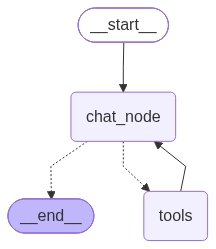

In [71]:
chatbot

In [72]:
result = chatbot.invoke({
    "messages": [
        HumanMessage(content="What is RAG?")
    ]
})

print(result)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash-lite is no longer available to new users. Please update your code to use a newer model for the latest features and improvements. We recommend you to use the Interactions API (https://ai.google.dev/gemini-api/docs/migrate-to-interactions).', 'status': 'NOT_FOUND'}}